In [52]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from neuralnet import NeuralNetwork
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

In [53]:
# 1. Carregar os dados limpos
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

X = df['Text']
y = df['Label']

# 2. Converter as Labels (Texto) para One-Hot Encoding (Obrigatório para Softmax!)
y_encoded = pd.get_dummies(y).astype(int).values
classes = pd.get_dummies(y).columns
print(f"Classes detetadas: {list(classes)}")

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 4. TF-IDF (Transformar palavras em números)
# max_features=2000 para não sobrecarregar a implementação própria (Numpy puro)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# Importante: A nossa rede precisa de Arrays Densos (.toarray()) e não matrizes esparsas
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print(f"Formato de Entrada do Treino: {X_train_tfidf.shape}")

Classes detetadas: ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
Formato de Entrada do Treino: (3944, 2000)


In [54]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset = TextDataset(X_train_tfidf, y_train)
test_dataset = TextDataset(X_test_tfidf, y_test)

In [ ]:
net = NeuralNetwork(epochs=60, batch_size=64, learning_rate=0.05, verbose=True,
                    loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Camada Oculta: 64 Neurónios com ativação ReLU
net.add(DenseLayer(64, input_shape=(n_features,)))
net.add(ReLUActivation())

# Camada de Saída: 5 Neurónios (porque temos 5 classes) com ativação Softmax
net.add(DenseLayer(5))
net.add(SoftmaxActivation())

print("A iniciar o treino da rede...")
net.fit(train_dataset)

A iniciar o treino da rede...
Epoch 1/60 - loss: 1.6140 - accuracy: 0.3471
Epoch 10/60 - loss: 1.3599 - accuracy: 0.4820
Epoch 20/60 - loss: 1.1390 - accuracy: 0.5751
Epoch 30/60 - loss: 0.9492 - accuracy: 0.6526
Epoch 40/60 - loss: 0.8024 - accuracy: 0.7122
Epoch 50/60 - loss: 0.6852 - accuracy: 0.7533
Epoch 60/60 - loss: 0.5895 - accuracy: 0.7972



Accuracy no Teste: 75.18%


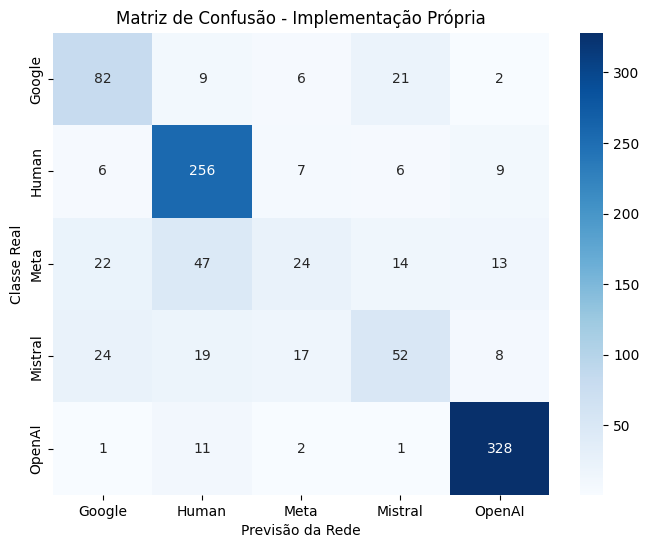

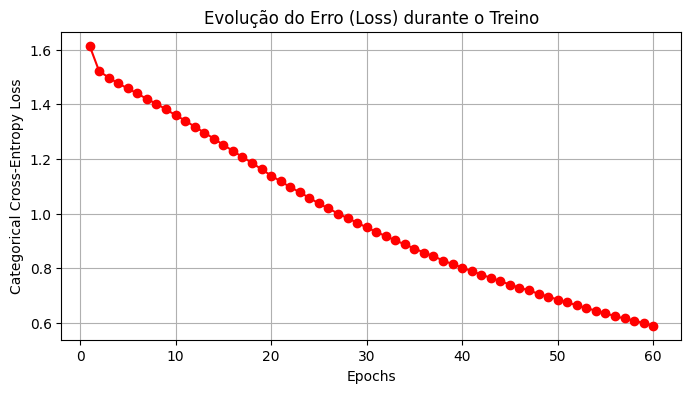

In [ ]:
# Fazer previsões no Teste
y_pred_prob = net.predict(test_dataset)

# Calcular a Accuracy
acc = net.score(test_dataset, y_pred_prob)
print(f"\nAccuracy no Teste: {acc*100:.2f}%")

# Converter probabilidades de volta para nomes das classes para a Matriz de Confusão
y_pred_classes = [classes[np.argmax(p)] for p in y_pred_prob]
y_true_classes = [classes[np.argmax(t)] for t in y_test]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Implementação Própria')
plt.ylabel('Classe Real')
plt.xlabel('Previsão da Rede')
plt.show()

# Gráfico do Loss ao longo das Epochs
epochs = list(net.history.keys())
losses = [net.history[e]['loss'] for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, losses, marker='o', color='red')
plt.title('Evolução do Erro (Loss) durante o Treino')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.grid()
plt.show()